In [9]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from src.models.utils import *
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import pearsonr
import numpy as np
from sklearn.linear_model import LinearRegression


merged_df_path = os.path.join(project_root, "data", "processed", "joined_df.csv")
merged_df = pd.read_csv(merged_df_path, encoding='utf-8')
power_plants = merged_df[['name', 'code']].drop_duplicates()
power_plants = power_plants[power_plants['code'].str.startswith("G")]

In [101]:
merged_df2 = merged_df[merged_df['is_good_peak'] >= 3]
merged_df2 = merged_df2[merged_df2[('sen_temperature')] >= 5]
merged_df2 = merged_df2[merged_df2[('sen_temperature')] < 50]
merged_df2 = merged_df2[merged_df2['generation'] <= 175]
merged_df2 = merged_df2[merged_df2['generation'] > 0]


In [102]:


errors = []
def show_line_max(i):
    row = power_plants.iloc[i]
    name = row['name']
    code = row['code']
    print(name, code)
    filtered_df = merged_df2[(merged_df2['name'] == name) & (merged_df2['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    hist, bin_edges = np.histogram(senstemps, bins=101)
    group_indices = np.digitize(senstemps, bin_edges) - 1
    tuples = []
    for g in np.unique(group_indices):
        mask = group_indices == g
        tuples.append((senstemps[mask].mean(), max(gens[mask])))
    X = np.array([a for a, b in tuples])
    y = np.array([b for a, b in tuples])
    model = LinearRegression()
    X = X.reshape(-1, 1)
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.scatter(senstemps, gens, s=1, alpha=0.2)
    plt.plot(X, y_pred, color="red")
    plt.scatter(X, y, s=3)
    error = compute_relative_rmse(y_pred, y)
    print(error)
    errors.append(error)
    plt.show()

# i = 46
# 
# show_line_max(i)

In [103]:
bad_units = [2, 8, 9, 10, 11, 17, 19, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41]
good_units = [x for x in range(46) if x not in bad_units]

پرند G16
2.0917226769767665


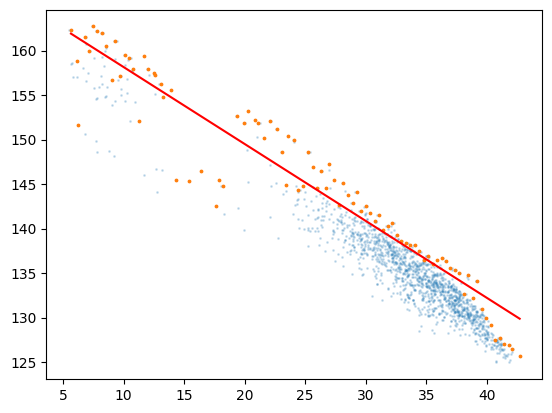

پرند G14
1.84971860066025


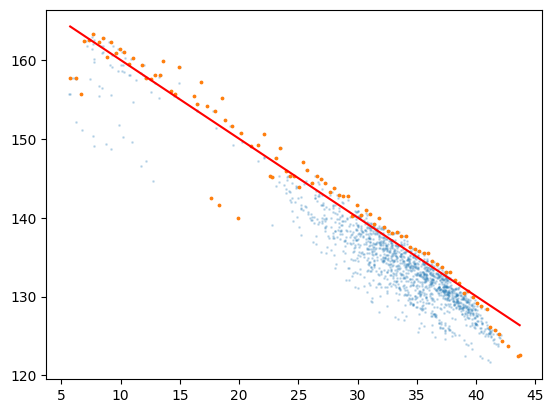

پرند G13
1.7506356862764134


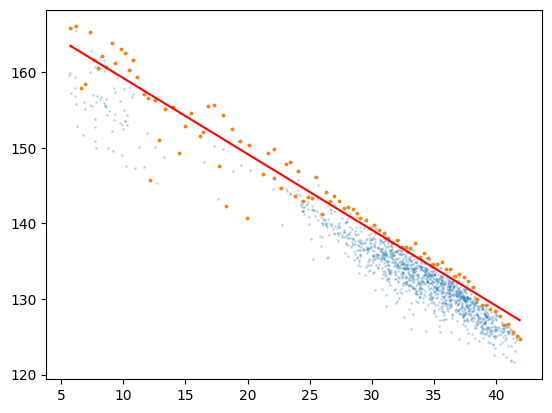

پرند G11
2.9530651380729394


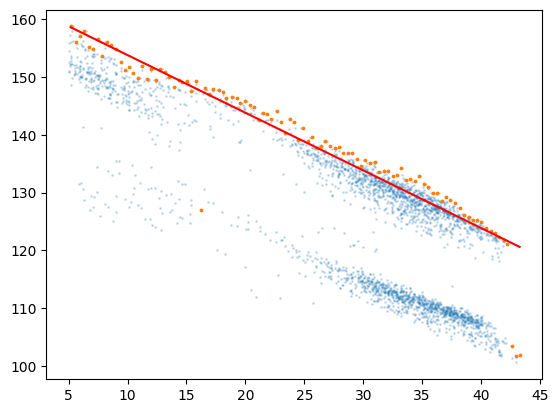

پرند G15
2.088029623961696


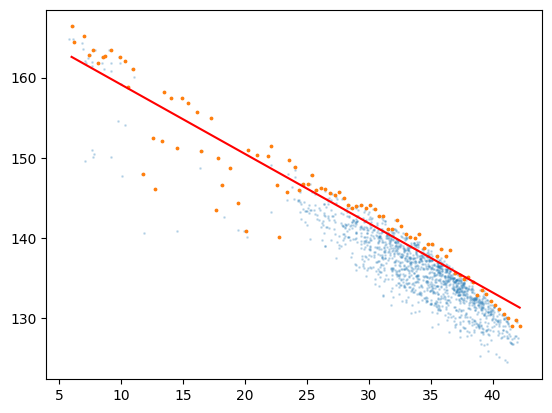

شهدای پیروز - بهبهان G12
3.7135566106695044


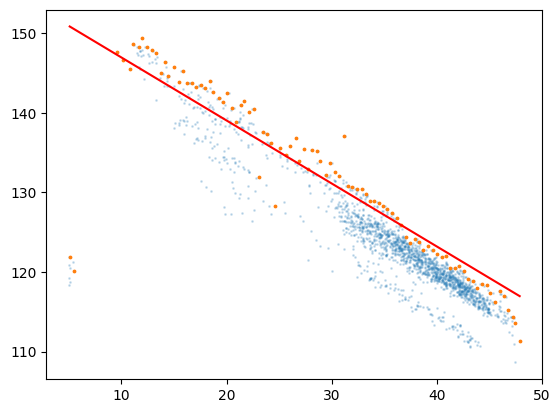

شهدای پیروز - بهبهان G11
4.249037892919161


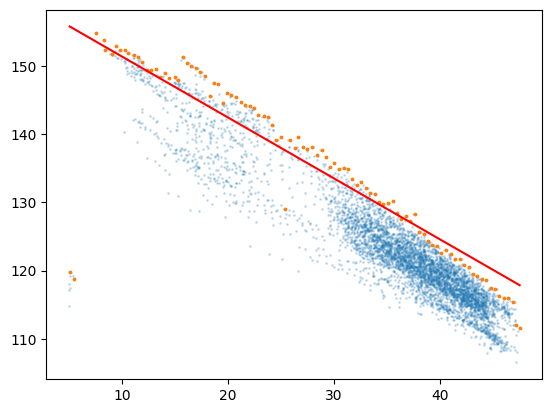

جنوب اصفهان - چهلستون G11
2.580317066421301


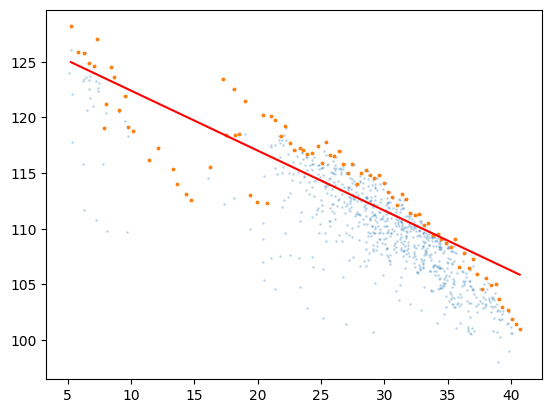

سبلان G16
1.692812855557429


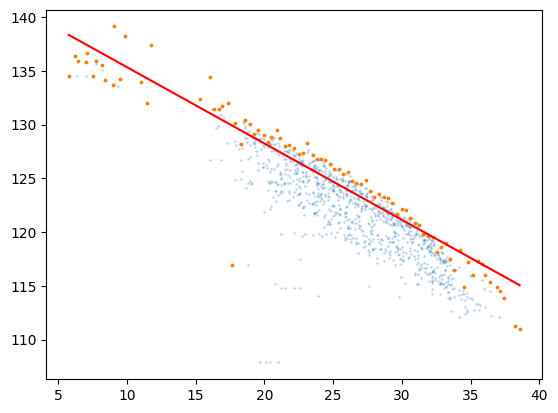

سبلان G14
1.726947220495677


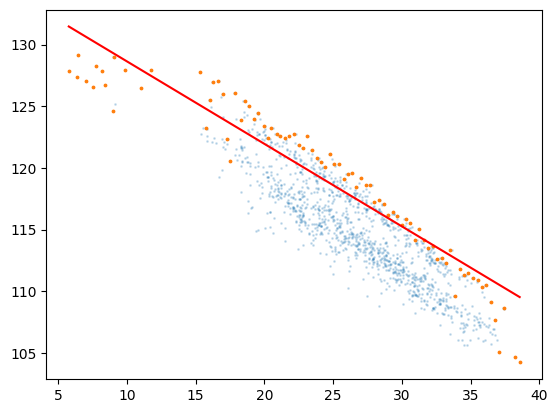

سبلان G13
1.9014808681210527


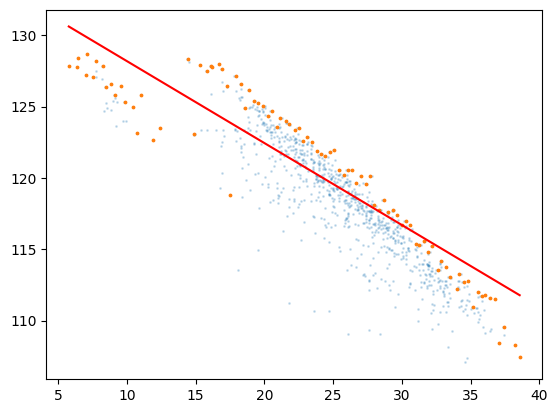

سبلان G15
1.2179698152550489


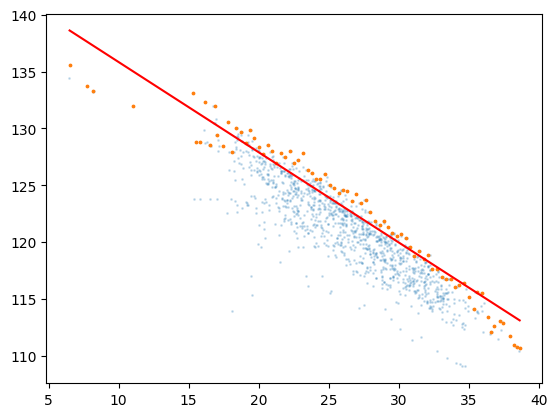

سبلان G12
1.1184402901007717


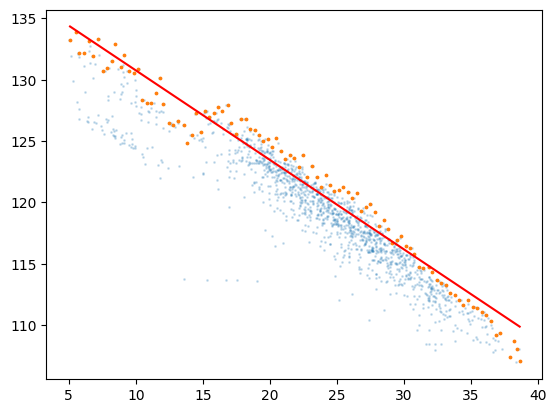

سیکل ترکیبی ارومیه G14
2.2601681042914623


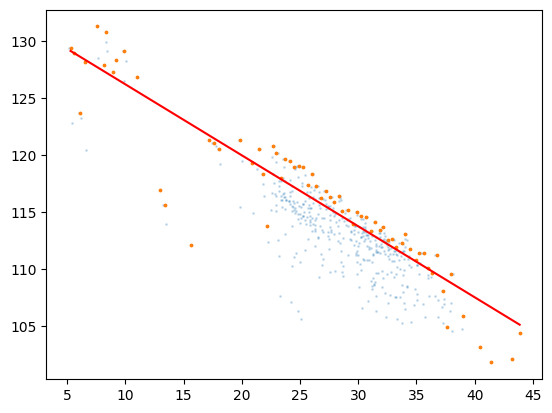

سیکل ترکیبی ارومیه G13
2.2424777530553768


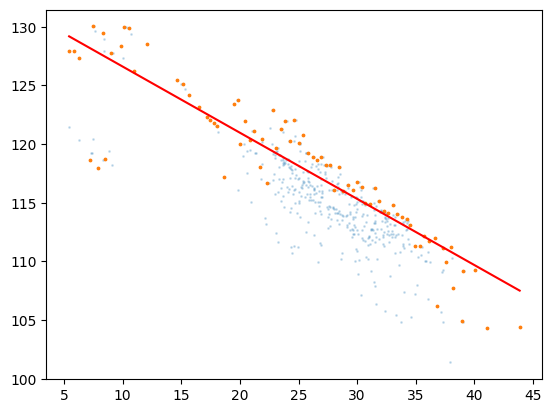

سیکل ترکیبی ارومیه G12
2.8377254522496256


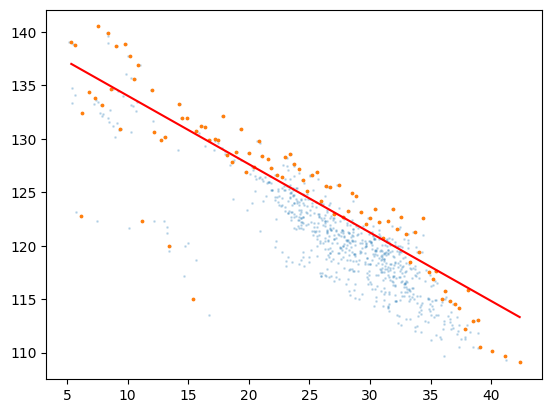

سیکل ترکیبی ارومیه G15
1.8240237161779038


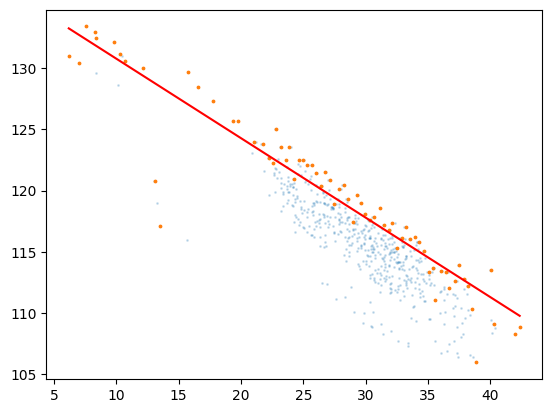

سیکل ترکیبی ارومیه G16
1.650763481683095


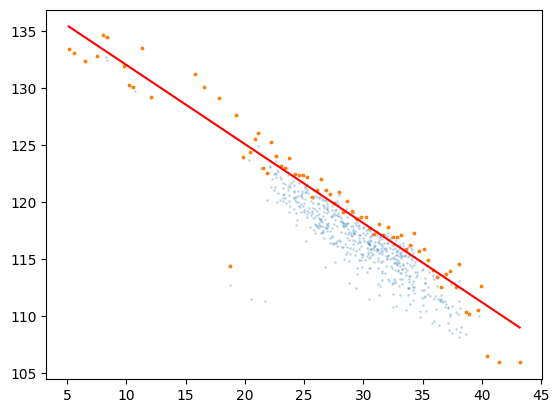

سیکل ترکیبی ارومیه G11
3.4695826331082555


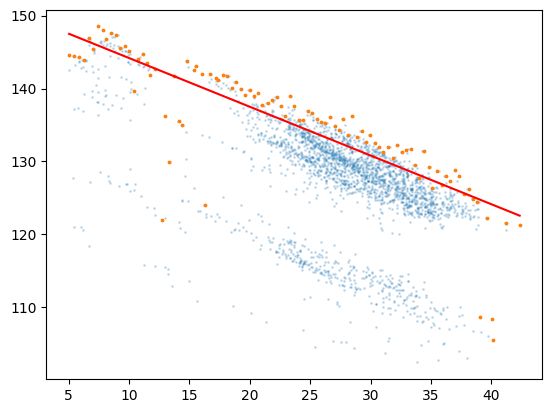

سیکل ترکیبی یزد G12
1.3643658484154755


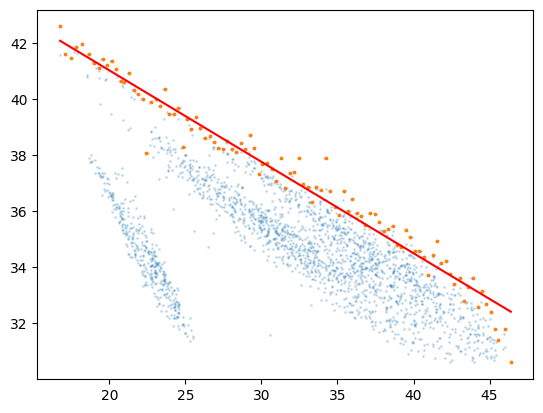

سیکل ترکیبی یزد G11
3.0283479322098588


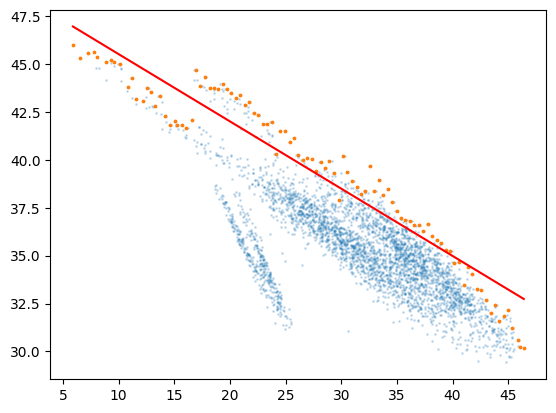

حافظ G16
1.4321676466943962


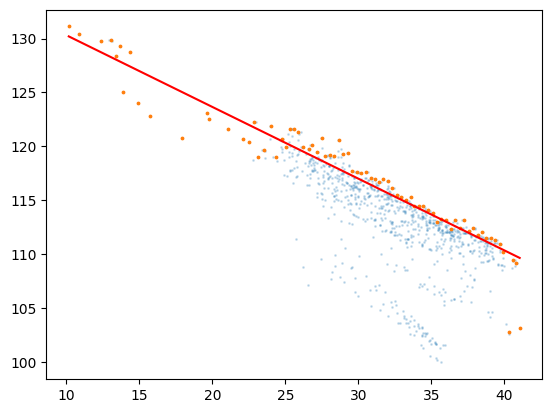

حافظ G11
1.9641170547188576


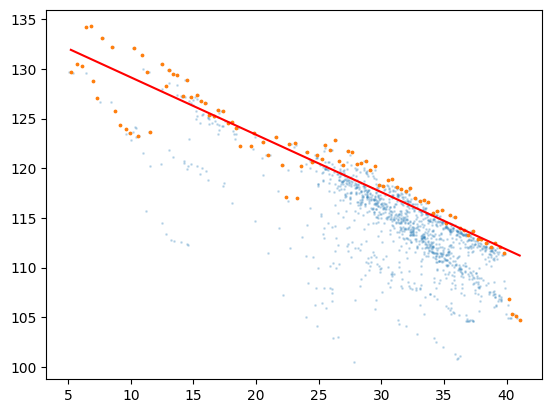

حافظ G15
1.2057599706913602


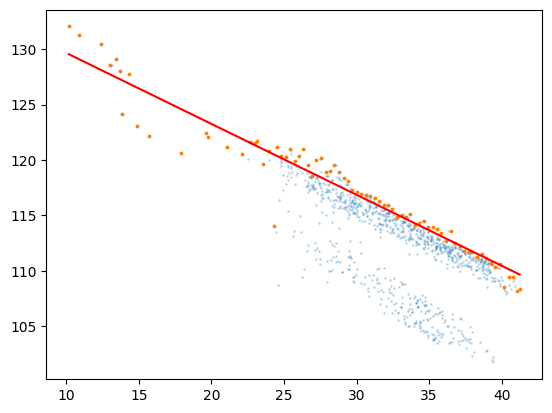

حافظ G12
1.1908109061132637


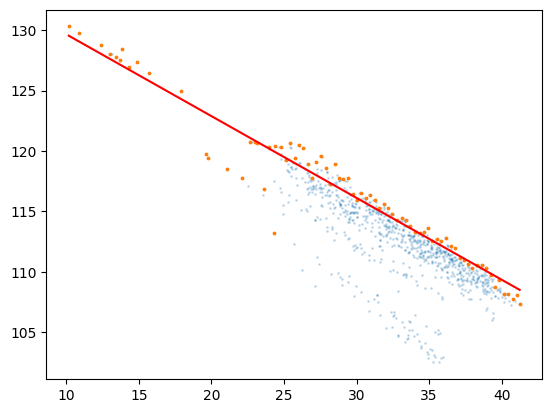

حافظ G14
1.5059157721464056


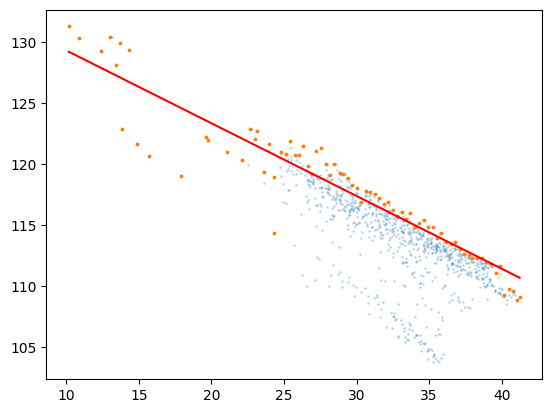

حافظ G13
1.5575927644856469


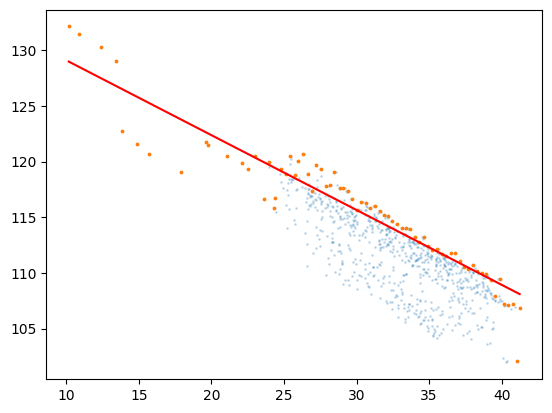

In [104]:
for i in good_units:
    show_line_max(i)

پرند G12
4.758903618682561


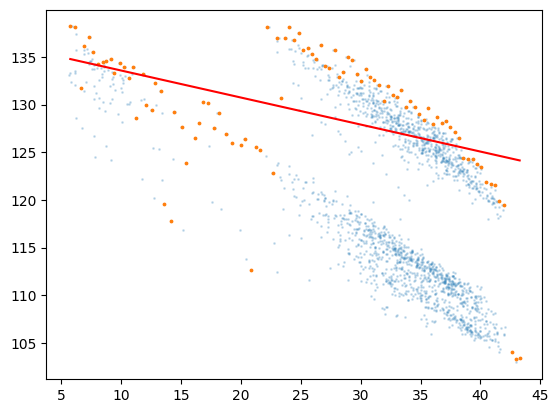

جنوب اصفهان - چهلستون G15
1.5241620971959564


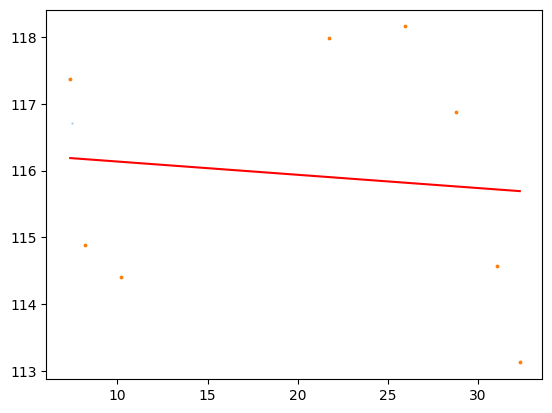

جنوب اصفهان - چهلستون G14
0.7864975072729867


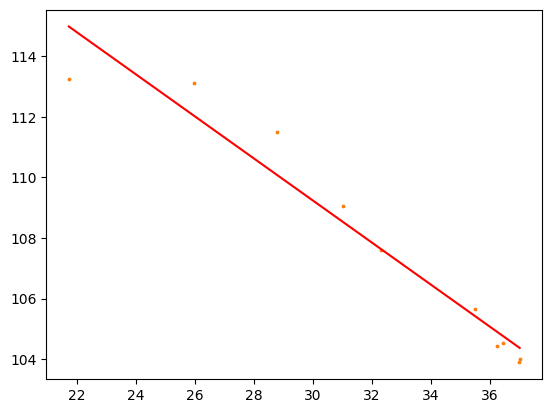

جنوب اصفهان - چهلستون G13
0.9011124285962652


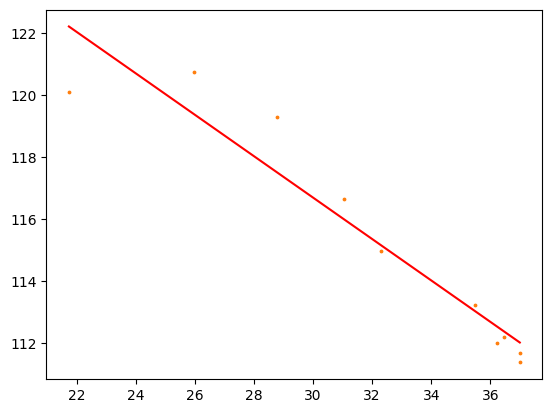

جنوب اصفهان - چهلستون G12
2.1268176978837805


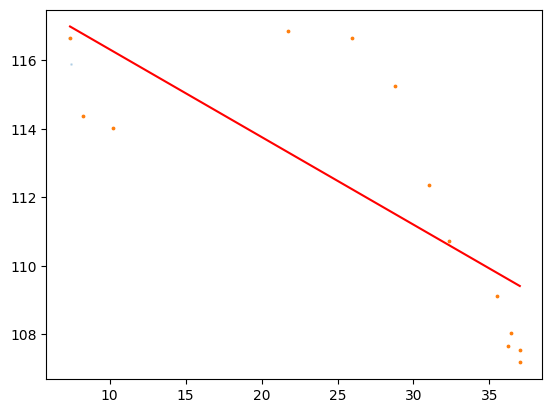

جنوب اصفهان - چهلستون G16
0.7246201537711102


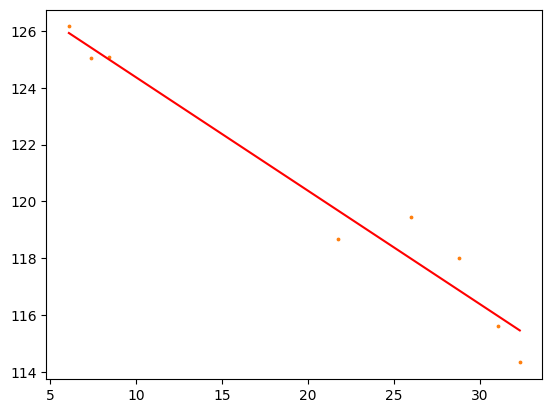

سبلان G11
1.4038368512271733


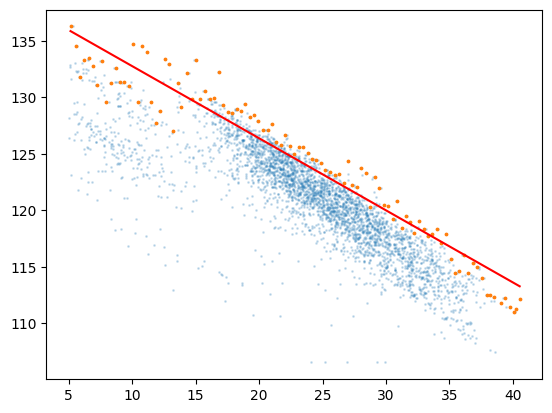

سیکل ترکیبی شیروان G16
2.1731538919427726


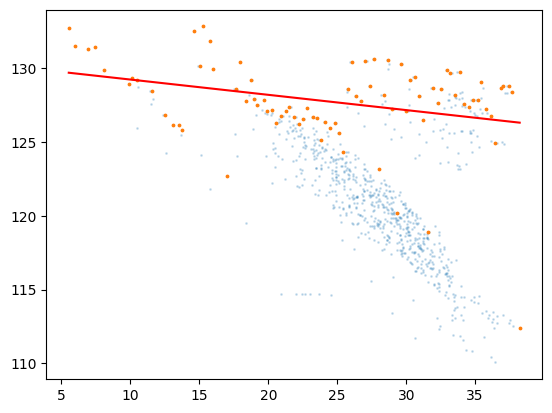

سیکل ترکیبی شیروان G11
3.4732618114337517


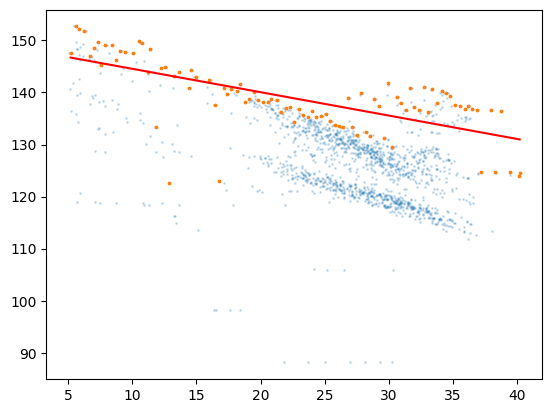

سیکل ترکیبی شیروان G15
3.892941735639492


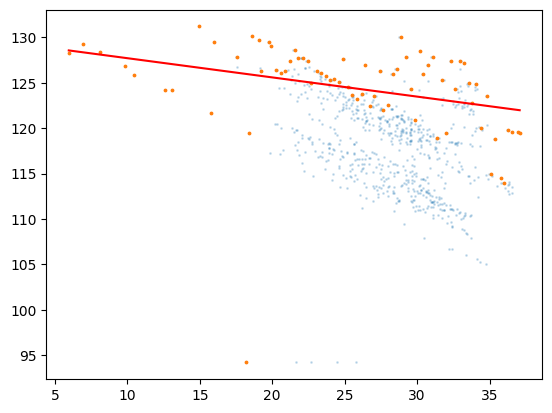

سیکل ترکیبی شیروان G12
2.9638376130217186


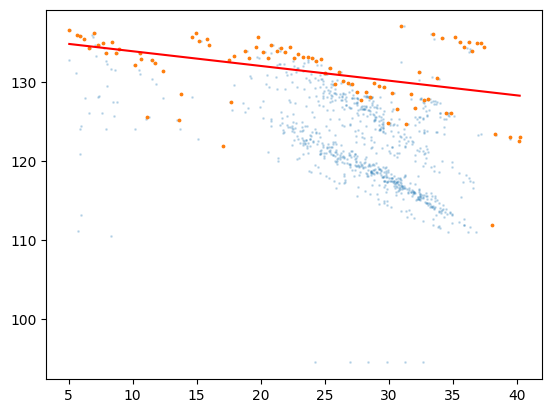

سیکل ترکیبی شیروان G14
2.0420518151902125


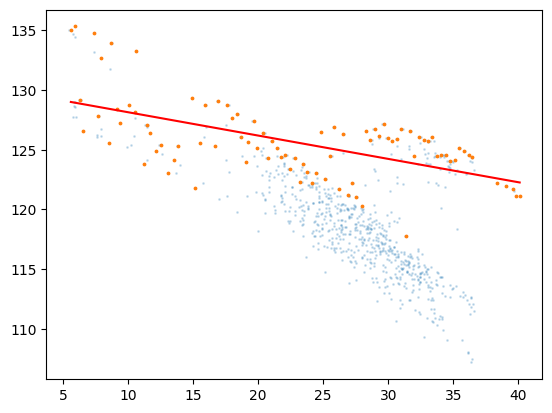

سیکل ترکیبی شیروان G13
2.146046855905834


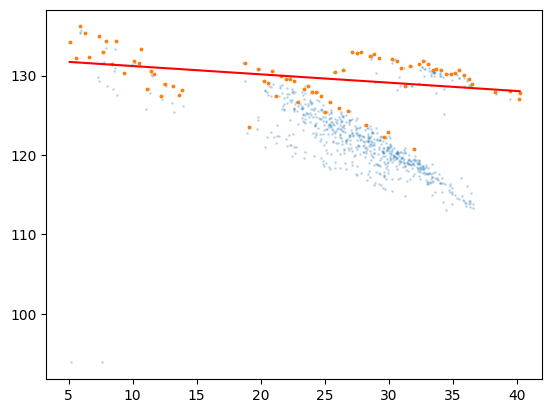

عسلویه G15
1.9723415492315641


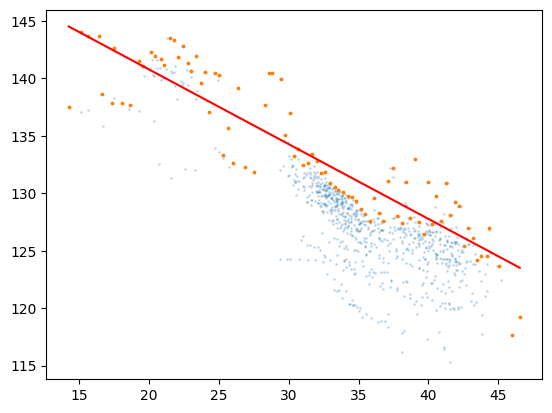

عسلویه G16
2.359638861702011


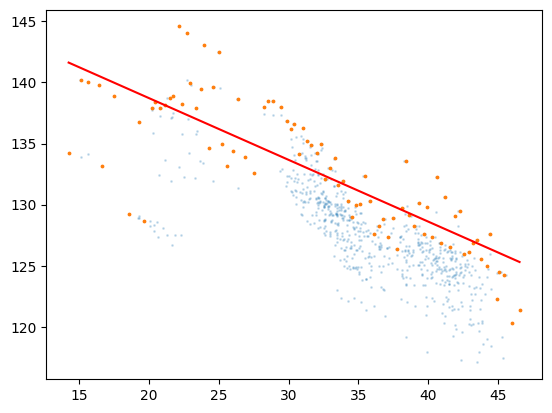

عسلویه G14
2.308230229711444


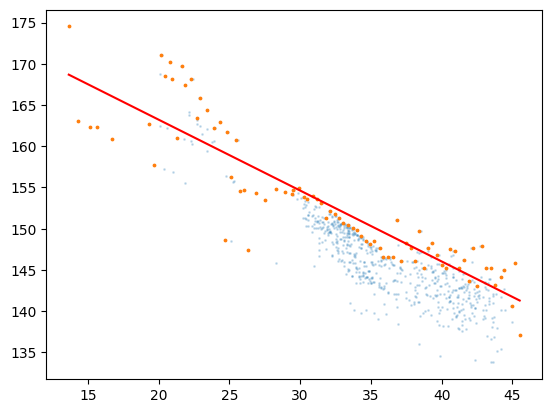

عسلویه G13
1.9605058674246125


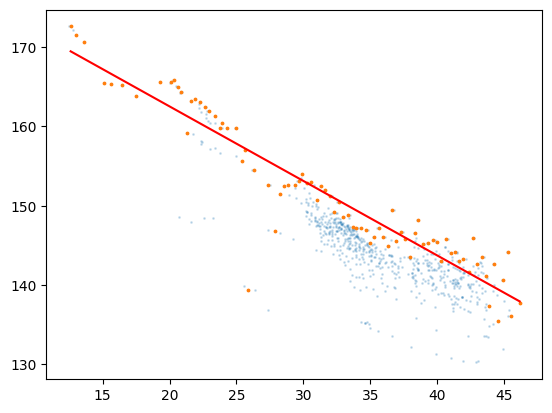

عسلویه G11
1.8104018786235638


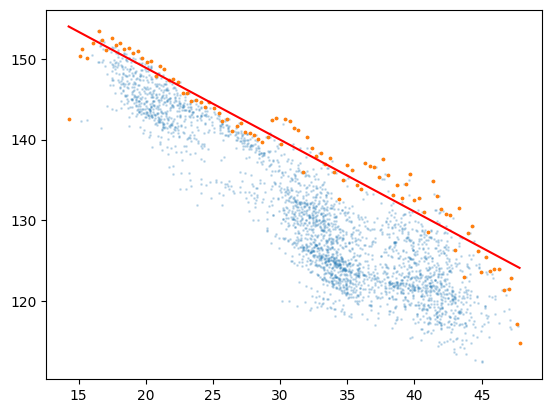

عسلویه G12
2.2967382711252924


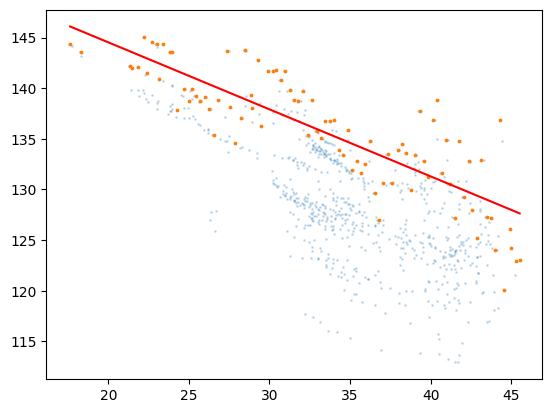

In [105]:
for i in bad_units:
    show_line_max(i)

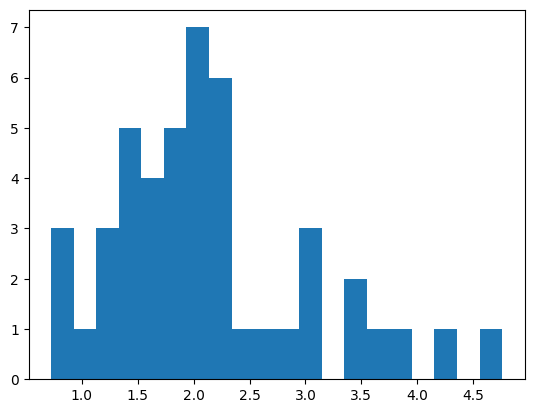

In [106]:
plt.hist(errors,bins=20)
plt.show()

In [107]:
errors = np.array(errors)
indices = [idx for idx in range(len(errors)) if errors[idx] > 2]
indices = np.array(indices)

In [100]:
print(indices)
bad_units = np.array(bad_units)
print(bad_units)

[ 3  6 18 19 20 22 25 27 28 29 30 31 32 33 35 36 37 40 41 42 43 44 45]
[ 2  8  9 10 11 17 19 28 29 30 31 32 33 34 35 36 37 40 41]
